In [15]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(23)

mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.eye(3)
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.eye(3)
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

In [16]:
df = pd.concat([df, df1], ignore_index=True)
df = df.sample(n=40, random_state=42).reset_index(drop=True)
df.head()

,feature1,feature2,feature3,target
0,-0.992574,-0.161346,1.192404,1
1,-0.420844,-0.551989,-0.121098,1
2,-0.045438,1.040886,-0.094035,1
3,0.898907,0.435960,0.820964,0
4,0.322272,0.060343,-1.043450,1


In [17]:
fig = px.scatter_3d(
    df, x='feature1', y='feature2', z='feature3',
    color=df['target'].astype(str)
)
fig.update_traces(marker=dict(size=8, line=dict(width=2, color='DarkSlateGrey')))
fig.show()

In [18]:
scaler = StandardScaler()
df[['feature1', 'feature2', 'feature3']] = scaler.fit_transform(df[['feature1', 'feature2', 'feature3']])

covariance_matrix = np.cov(df[['feature1', 'feature2', 'feature3']].T)
print(covariance_matrix)

[[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [19]:
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

idx = eigen_values.argsort()[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

print(eigen_values)
print(eigen_vectors)

[1.3536065  0.94557084 0.77774573]
[[-0.53875915 -0.69363291  0.47813384]
 [-0.65608325 -0.01057596 -0.75461442]
 [-0.52848211  0.72025103  0.44938304]]


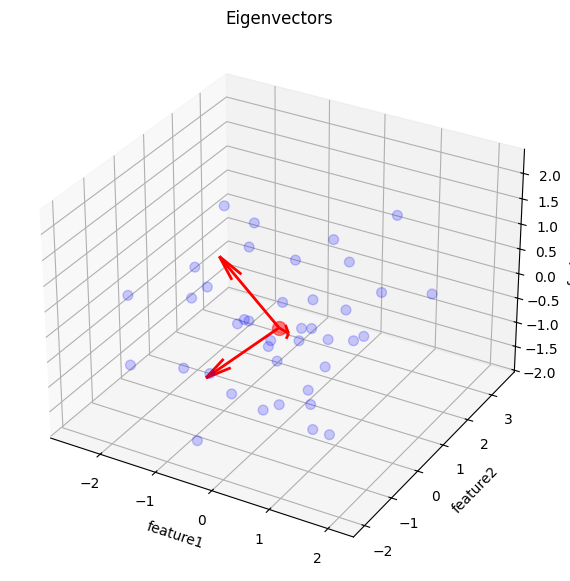

In [20]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

mean_vals = df[['feature1', 'feature2', 'feature3']].mean()

ax.scatter(df['feature1'], df['feature2'], df['feature3'], s=50, c='blue', alpha=0.2)
ax.scatter(*mean_vals, s=100, c='red', alpha=0.5)

for v in eigen_vectors.T:
    ax.quiver(
        mean_vals['feature1'], mean_vals['feature2'], mean_vals['feature3'],
        v[0], v[1], v[2],
        color='r', linewidth=2, length=1.5
    )

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')
plt.title('Eigenvectors')
plt.show()

In [21]:
pc = eigen_vectors[:, 0:2]
print(pc)

[[-0.53875915 -0.69363291]
 [-0.65608325 -0.01057596]
 [-0.52848211  0.72025103]]


In [22]:
transformed_data = df[['feature1', 'feature2', 'feature3']].to_numpy() @ pc

new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].astype(str)
new_df.head()

,PC1,PC2,target
0,0.817930,1.203797,1
1,1.403371,0.029261,1
2,0.216358,-0.197431,1
3,-0.274866,-0.184906,0
4,1.098223,-1.011722,1


In [23]:
fig = px.scatter(
    new_df, x='PC1', y='PC2', color='target',
    color_discrete_sequence=px.colors.qualitative.G10
)
fig.update_traces(marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')))
fig.show()